# BulkFormer — Evaluation & Multi-organism Visualization
Sections:
1. Load model
2. Load data (human demo OR Arabidopsis microarray — one config cell controls everything)
3. Viz A — Imputation quality
4. Viz B — Sample embedding UMAP
5. Viz C — Gene embedding similarity


In [9]:
import os, json
print("os, json OK")

import numpy as np
print("numpy OK")

import pandas as pd
print("pandas OK")

import torch
print("torch OK")

import matplotlib
print("matplotlib OK")

import matplotlib.pyplot as plt
print("matplotlib.pyplot OK")

from collections import OrderedDict
print("collections OK")

from scipy.stats import pearsonr, spearmanr
print("scipy OK")

from sklearn.preprocessing import LabelEncoder
print("sklearn LabelEncoder OK")

from sklearn.cluster import KMeans
print("sklearn KMeans OK")

from sklearn.metrics.pairwise import cosine_similarity
print("sklearn cosine_similarity OK")

import umap
print("umap OK")

from tqdm import tqdm
print("tqdm OK")

from torch_geometric.typing import SparseTensor
print("torch_geometric OK")

from utils.BulkFormer import BulkFormer
print("BulkFormer OK")

from model.config import model_params
print("model_params OK")

os.makedirs('figures', exist_ok=True)
os.makedirs('embeddings', exist_ok=True)

matplotlib.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#0f1117',
    'axes.edgecolor': '#3a3a4a',   'axes.labelcolor': '#c8c8d8',
    'xtick.color': '#7a7a9a',      'ytick.color': '#7a7a9a',
    'text.color': '#c8c8d8',       'grid.color': '#2a2a3a',
    'grid.linewidth': 0.5,         'font.family': 'monospace',
})
ACCENT  = '#00e5c0'
PALETTE = ['#00e5c0','#ff6b6b','#ffd166','#a78bfa','#38bdf8','#fb923c',
           '#4ade80','#f472b6','#e879f9','#94a3b8','#f97316','#06b6d4']
print('All done')

os, json OK
numpy OK
pandas OK
torch OK
matplotlib OK
matplotlib.pyplot OK
collections OK
scipy OK
sklearn LabelEncoder OK
sklearn KMeans OK
sklearn cosine_similarity OK
umap OK
tqdm OK
torch_geometric OK
BulkFormer OK
model_params OK
All done


## 1 · Load model
**OOM fix**: graph stays on CPU. Only expression batches move to GPU.
This matches the original notebook and reduces VRAM from ~3GB to ~600MB.

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
if device == 'cuda':
    torch.cuda.empty_cache()
    print(f'VRAM free before load: {torch.cuda.mem_get_info()[0]/1e9:.1f} GB')

# Graph stays on CPU — key difference vs previous version
graph_ei  = torch.load('data/downloads/G_gtex.pt',        map_location='cpu', weights_only=False)
graph_w   = torch.load('data/downloads/G_gtex_weight.pt', map_location='cpu', weights_only=False)
graph_cpu = SparseTensor(row=graph_ei[1], col=graph_ei[0], value=graph_w)  # stays CPU

gene_emb  = torch.load('data/downloads/esm2_feature_concat.pt', map_location='cpu', weights_only=False)
gene_info = pd.read_csv('data/downloads/bulkformer_gene_info.csv')
gene_list = gene_info['ensg_id'].drop_duplicates().tolist()
gene_info = gene_info.drop_duplicates(subset='ensg_id').reset_index(drop=True)
print(f'gene_list length: {len(gene_list)}')  # must print 20010
gene_idx  = {g: i for i, g in enumerate(gene_list)}

model_params['graph']    = graph_cpu
model_params['gene_emb'] = gene_emb
model = BulkFormer(**model_params).to(device)

ckpt = torch.load('model/BulkFormer_37M.pt', weights_only=False)
sd   = OrderedDict((k[7:] if k.startswith('module.') else k, v) for k, v in ckpt.items())
model.load_state_dict(sd)
model.eval()

print(f'Model loaded — {sum(p.numel() for p in model.parameters())/1e6:.0f}M params')
if device == 'cuda':
    print(f'VRAM used after load: {torch.cuda.memory_allocated()/1e9:.2f} GB')

Device: cuda
VRAM free before load: 6.3 GB
gene_list length: 20011
Model loaded — 13M params
VRAM used after load: 0.69 GB


## 2 · Data configuration
**Change `ORGANISM` to switch datasets. Everything downstream adapts automatically.**
- `'human'` — BulkFormer demo.csv
- `'arabidopsis'` — your RMA microarray matrix


In [ ]:
# ════════════════════════════════════════════════════
#  CONFIGURE HERE
# ════════════════════════════════════════════════════
ORGANISM   = 'human'   # 'human' | 'arabidopsis'
N_SAMPLES  = 64        # samples to run (increase for full dataset)
BATCH_SIZE = 8         # reduce to 4 if still OOM

HUMAN_EXPR_PATH = 'data/downloads/demo.csv'

ATH_EXPR_PATH  = '/home/alex/Documents/GitHub/Dataset_fusion_Microarray/new_storage/final_data/RMA_Microarray_Combined.csv'
ATH_ORTHO_PATH = 'metadata/arabidopsis_to_human_hgnc.json'
ATH_META_PATH  = None          # path to metadata CSV, or None for k-means
ATH_META_COL   = 'treatment'   # column to colour by (ignored if META_PATH is None)
# ════════════════════════════════════════════════════

In [24]:
def align_to_vocab(expr_df, gene_list):
    missing   = list(set(gene_list) - set(expr_df.columns))
    pad       = pd.DataFrame(-10, index=expr_df.index, columns=missing)
    aligned   = pd.concat([expr_df, pad], axis=1)[gene_list]
    mask_prob = len(missing) / len(gene_list)
    return aligned, mask_prob


if ORGANISM == 'human':
    expr_df = pd.read_csv(HUMAN_EXPR_PATH)
    # Sync gene_list to only genes present in this dataset
    missing_from_expr = set(gene_list) - set(expr_df.columns)
    print(f'Genes in gene_list but missing from expr: {missing_from_expr}')
    gene_list = [g for g in gene_list if g in set(expr_df.columns)]
    gene_idx  = {g: i for i, g in enumerate(gene_list)}
    print(f'gene_list length after sync: {len(gene_list)}')
    input_df, mask_prob = align_to_vocab(expr_df, gene_list)
    print(f'input_df shape: {input_df.shape}')  # must match gene_list length
    sample_labels = None
    model_params['gene_length'] = len(gene_list)
    organism_tag  = 'Human (BulkFormer demo)'

elif ORGANISM == 'arabidopsis':
    expr_df = pd.read_csv(ATH_EXPR_PATH, index_col=0)
    if expr_df.shape[0] > expr_df.shape[1] and str(expr_df.columns[0]).startswith('AT'):
        expr_df = expr_df.T
    print(f'Arabidopsis microarray: {expr_df.shape}')

    with open(ATH_ORTHO_PATH) as f:
        ortho_map = json.load(f)
    expr_df.columns = expr_df.columns.str.replace(r'\.\d+$', '', regex=True)
    mapped = {t: e for t, e in ortho_map.items() if t in expr_df.columns and e in gene_idx}
    print(f'Mapped {len(mapped)}/{len(expr_df.columns)} genes '
          f'({len(mapped)/len(gene_list)*100:.1f}% vocab coverage)')

    ensg_df = expr_df[list(mapped.keys())].copy()
    ensg_df.columns = [mapped[c] for c in ensg_df.columns]
    ensg_df = ensg_df.T
    ensg_df['_m'] = ensg_df.mean(axis=1)
    ensg_df = ensg_df.sort_values('_m', ascending=False)
    ensg_df = ensg_df[~ensg_df.index.duplicated(keep='first')].drop(columns='_m').T

    input_df, mask_prob = align_to_vocab(ensg_df, gene_list)

    if ATH_META_PATH:
        meta = pd.read_csv(ATH_META_PATH, index_col=0)
        sample_labels = meta.loc[input_df.index, ATH_META_COL].values
    else:
        sample_labels = None
    organism_tag = 'Arabidopsis thaliana (microarray)'

else:
    raise ValueError(f'Unknown ORGANISM: {ORGANISM}')

expr_arr = input_df.values[:N_SAMPLES].astype(np.float32)
if sample_labels is not None:
    sample_labels = sample_labels[:N_SAMPLES]

print(f'\nOrganism  : {organism_tag}')
print(f'Samples   : {len(expr_arr)}')
print(f'mask_prob : {mask_prob:.4f}  ({mask_prob*100:.1f}% genes absent from vocab)')

Arabidopsis microarray: (22600, 14983)


FileNotFoundError: [Errno 2] No such file or directory: 'metadata/arabidopsis_to_human_hgnc.json'

In [13]:
def run_model(arr, batch_size=BATCH_SIZE, output_expr=False, mask_prob=0.0):
    results = []
    model.eval()
    # Move graph to same device as model
    model.graph = model.graph.to(device)
    with torch.no_grad():
        for i in tqdm(range(0, len(arr), batch_size)):
            batch = torch.tensor(arr[i:i+batch_size], dtype=torch.float32).to(device)
            out   = model(batch, mask_prob=mask_prob, output_expr=output_expr)
            results.append(out.cpu())
    if output_expr:
        return np.concatenate([r.numpy() for r in results], axis=0)
    return torch.cat(results, dim=0)

## 3 · Viz A — Imputation quality

In [14]:
MASK_RATIO = 0.15
rng = np.random.default_rng(42)
masked_input = expr_arr.copy()
true_vals, pred_vals, mask_indices = [], [], []

for s in range(len(expr_arr)):
    obs    = np.where(expr_arr[s] != -10)[0]
    chosen = rng.choice(obs, size=int(len(obs) * MASK_RATIO), replace=False)
    mask_indices.append(chosen)
    true_vals.append(expr_arr[s, chosen])
    masked_input[s, chosen] = -10.0
    
print(f'expr_arr shape: {expr_arr.shape}')
print(f'masked_input shape: {masked_input.shape}')
print(f'model gene_length param: {model.gene_length}')
print(f'global_expr_proj input size: {model.global_expr_proj[0].in_features}')
print(gene_list[:3])   # should be ['ENSG...', 'ENSG...', 'ENSG...']
print(len(gene_list))  # should be 20010
imputed = run_model(masked_input, output_expr=True, mask_prob=MASK_RATIO)
for s in range(len(expr_arr)):
    pred_vals.append(imputed[s, mask_indices[s]])

true_all = np.concatenate(true_vals)
pred_all = np.concatenate(pred_vals)
pcc, _   = pearsonr(true_all, pred_all)
scc, _   = spearmanr(true_all, pred_all)
errors   = pred_all - true_all
print(f'[{organism_tag}]  PCC={pcc:.4f}  SCC={scc:.4f}')

expr_arr shape: (64, 20010)
masked_input shape: (64, 20010)
model gene_length param: 20010
global_expr_proj input size: 20010
['ENSG00000000003', 'ENSG00000000005', 'ENSG00000000419']
20010


100%|██████████| 8/8 [00:01<00:00,  6.18it/s]


[Human (BulkFormer demo)]  PCC=0.7953  SCC=0.7226


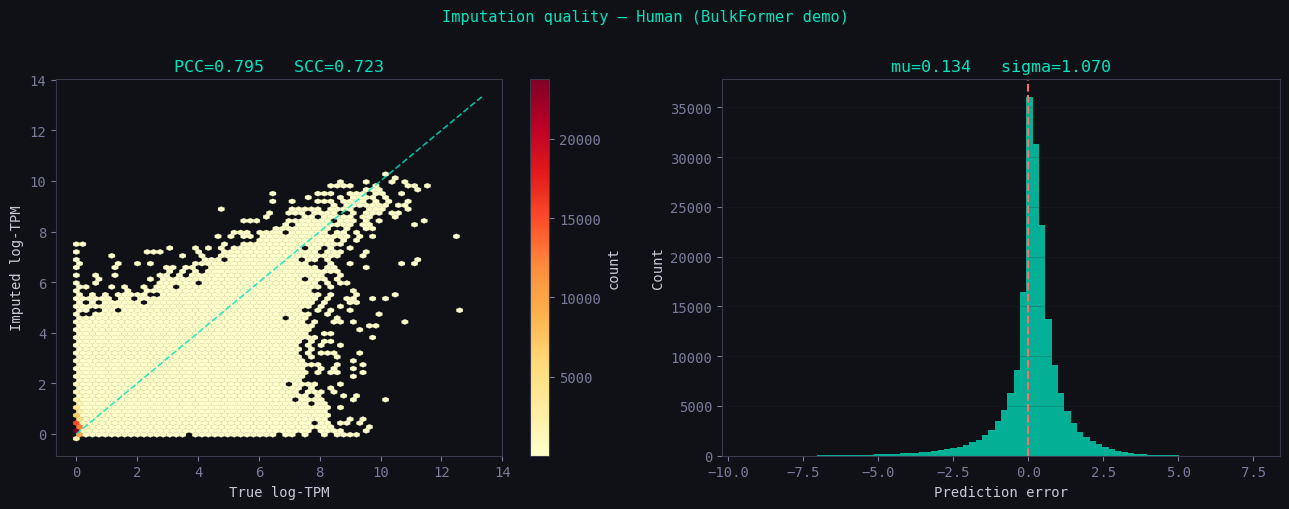

Saved to figures/imputation_human.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Imputation quality — {organism_tag}', color=ACCENT, fontsize=11, y=1.01)

ax = axes[0]
hb = ax.hexbin(true_all, pred_all, gridsize=60, cmap='YlOrRd', mincnt=1, linewidths=0.2)
lim = max(true_all.max(), pred_all.max()) * 1.05
ax.plot([0, lim], [0, lim], '--', color=ACCENT, lw=1.2, alpha=0.8)
ax.set_xlabel('True log-TPM'); ax.set_ylabel('Imputed log-TPM')
ax.set_title(f'PCC={pcc:.3f}   SCC={scc:.3f}', color=ACCENT)
plt.colorbar(hb, ax=ax, label='count')

ax2 = axes[1]
ax2.hist(errors, bins=80, color=ACCENT, alpha=0.75, edgecolor='none')
ax2.axvline(0, color='#ff6b6b', lw=1.5, ls='--')
ax2.set_xlabel('Prediction error'); ax2.set_ylabel('Count')
ax2.set_title(f'mu={errors.mean():.3f}   sigma={errors.std():.3f}', color=ACCENT)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
fname = f'figures/imputation_{ORGANISM}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show(); print(f'Saved to {fname}')

## 4 · Viz B — Sample embedding UMAP

In [16]:
gene_emb_out = run_model(expr_arr, output_expr=False, mask_prob=mask_prob)
sample_emb   = gene_emb_out.mean(dim=1).numpy()   # [N, 643]
print(f'Sample embeddings: {sample_emb.shape}')

100%|██████████| 8/8 [00:01<00:00,  6.95it/s]


Sample embeddings: (64, 131)


/home/alex/miniconda3/envs/bulkformer_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


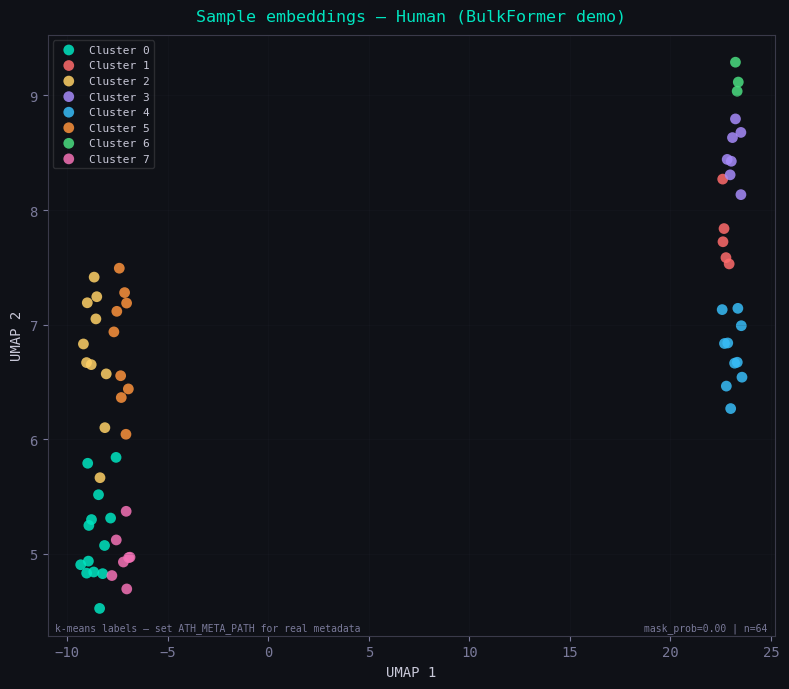

Saved to figures/umap_samples_human.png


In [17]:
reducer   = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
embedding = reducer.fit_transform(sample_emb)

if sample_labels is not None:
    le         = LabelEncoder()
    labels_enc = le.fit_transform(sample_labels)
    label_map  = {i: n for i, n in enumerate(le.classes_)}
else:
    K          = min(8, len(expr_arr) // 4)
    labels_enc = KMeans(n_clusters=K, random_state=42, n_init=10).fit_predict(sample_emb)
    label_map  = {i: f'Cluster {i}' for i in range(K)}

fig, ax = plt.subplots(figsize=(8, 7))
for i, lbl in label_map.items():
    mask = labels_enc == i
    ax.scatter(embedding[mask, 0], embedding[mask, 1],
               c=PALETTE[i % len(PALETTE)], label=lbl,
               s=60, alpha=0.85, edgecolors='none')
ax.set_xlabel('UMAP 1'); ax.set_ylabel('UMAP 2')
ax.set_title(f'Sample embeddings — {organism_tag}', color=ACCENT, pad=10)
ax.legend(framealpha=0.15, fontsize=8)
ax.grid(alpha=0.2)
if sample_labels is None:
    ax.text(0.01, 0.01, 'k-means labels — set ATH_META_PATH for real metadata',
            transform=ax.transAxes, fontsize=7, color='#7a7a9a')
ax.text(0.99, 0.01, f'mask_prob={mask_prob:.2f} | n={len(expr_arr)}',
        transform=ax.transAxes, fontsize=7, color='#7a7a9a', ha='right')
plt.tight_layout()
fname = f'figures/umap_samples_{ORGANISM}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show(); print(f'Saved to {fname}')

## 5 · Viz C — Gene embedding similarity

In [18]:
# Genes defined in ENSG IDs — same vocabulary for both organisms.
# For Arabidopsis, these are the human orthologs of conserved pathway genes.
# Override ATH_GENE_GROUPS with Arabidopsis-specific groups once you have
# the ortholog map (e.g. map known stress TFs like DREB2A, WRKY11 to ENSG).
GENE_GROUPS = {
    'Cell cycle':    ['ENSG00000105173','ENSG00000134057','ENSG00000135446','ENSG00000117399'],
    'Immune/stress': ['ENSG00000136244','ENSG00000232810','ENSG00000125538','ENSG00000163599'],
    'DNA repair':    ['ENSG00000012048','ENSG00000139618','ENSG00000141510','ENSG00000149311'],
    'Metabolism':    ['ENSG00000111640','ENSG00000106633','ENSG00000159111','ENSG00000067225'],
    'Transcription': ['ENSG00000101412','ENSG00000135679','ENSG00000198625','ENSG00000112033'],
}
# Set this to override when running Arabidopsis:
ATH_GENE_GROUPS = None

active_groups = ATH_GENE_GROUPS if (ORGANISM == 'arabidopsis' and ATH_GENE_GROUPS) else GENE_GROUPS

all_ids, all_names, all_groups = [], [], []
for grp, ids in active_groups.items():
    for gid in ids:
        if gid in gene_idx:
            row  = gene_info[gene_info['ensg_id'] == gid]
            name = row['gene_symbol'].values[0] if len(row) else gid
            all_ids.append(gid); all_names.append(name); all_groups.append(grp)

sel_idx = [gene_idx[g] for g in all_ids]
print(f'{len(sel_idx)} genes selected across {len(active_groups)} groups')

20 genes selected across 5 groups


/home/alex/miniconda3/envs/bulkformer_env/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


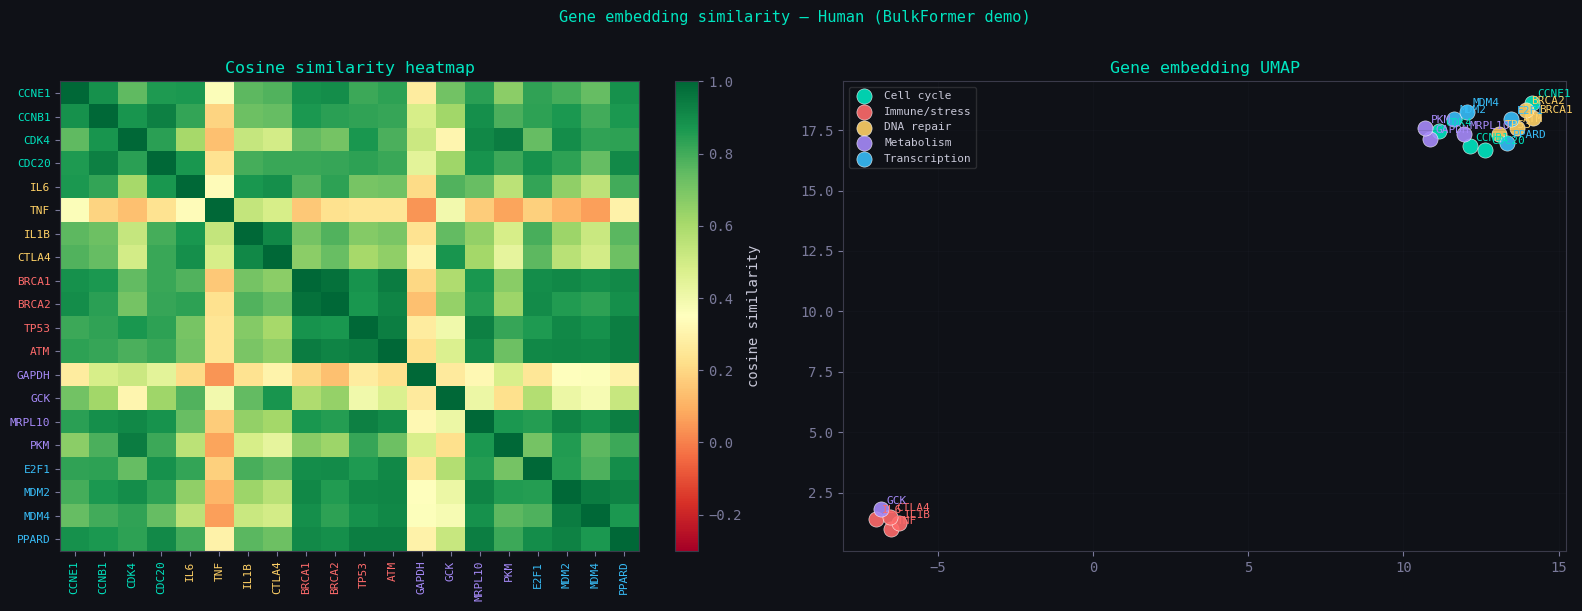

Saved to figures/gene_similarity_human.png


In [19]:
gene_vecs  = gene_emb_out[:, sel_idx, :640].mean(dim=0).numpy()
sim_matrix = cosine_similarity(gene_vecs)
group_enc  = LabelEncoder().fit_transform(all_groups)
group_cols = [PALETTE[i % len(PALETTE)] for i in group_enc]
n = len(all_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Gene embedding similarity — {organism_tag}', color=ACCENT, fontsize=11, y=1.01)

ax = axes[0]
im = ax.imshow(sim_matrix, cmap='RdYlGn', vmin=-0.3, vmax=1.0, aspect='auto')
ax.set_xticks(range(n)); ax.set_xticklabels(all_names, rotation=90, fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(all_names, fontsize=8)
for tick, col in zip(ax.get_xticklabels(), group_cols): tick.set_color(col)
for tick, col in zip(ax.get_yticklabels(), group_cols): tick.set_color(col)
plt.colorbar(im, ax=ax, label='cosine similarity')
ax.set_title('Cosine similarity heatmap', color=ACCENT)

ax2 = axes[1]
gr  = umap.UMAP(n_neighbors=4, min_dist=0.05, metric='cosine', random_state=42)
ge  = gr.fit_transform(gene_vecs)
for i, (grp, col) in enumerate(zip(active_groups.keys(), PALETTE)):
    mask = np.array(all_groups) == grp
    ax2.scatter(ge[mask,0], ge[mask,1], c=col, label=grp,
                s=120, edgecolors='white', linewidths=0.4, alpha=0.9)
    for j, nm in enumerate(np.array(all_names)[mask]):
        ax2.annotate(nm, ge[mask][j], fontsize=8, color=col,
                     xytext=(4,4), textcoords='offset points')
ax2.set_title('Gene embedding UMAP', color=ACCENT)
ax2.legend(framealpha=0.15, fontsize=8)
ax2.grid(alpha=0.2)

plt.tight_layout()
fname = f'figures/gene_similarity_{ORGANISM}.png'
plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show(); print(f'Saved to {fname}')

## 6 · Save embeddings

In [20]:
np.save(f'embeddings/{ORGANISM}_sample_embeddings.npy', sample_emb)
np.save(f'embeddings/{ORGANISM}_gene_embeddings.npy',   gene_emb_out.numpy())
print(f'Saved embeddings/{ORGANISM}_sample_embeddings.npy  {sample_emb.shape}')
print(f'Saved embeddings/{ORGANISM}_gene_embeddings.npy    {gene_emb_out.shape}')

Saved embeddings/human_sample_embeddings.npy  (64, 131)
Saved embeddings/human_gene_embeddings.npy    torch.Size([64, 20010, 131])
